# House Pricing Calculation

# Exploración y Procesamiento de Datos

Primero tenemos que leer el archivo CSV que se nos ha proporcionado. Para ello utilizaremos un paquete llamado `pandas`:

In [61]:
import pandas as pd

In [62]:
df = pd.read_csv('housepricedata.csv')

In [63]:
df

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1
...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,5,953,2,1,3,7,1,460,1
1456,13175,6,6,1542,2,0,3,7,2,500,1
1457,9042,7,9,1152,2,0,4,9,2,252,1
1458,9717,5,6,1078,1,0,2,5,0,240,0


El conjunto de datos que tenemos ahora está en lo que llamamos un `dataframe` de pandas. Para convertirlo en un `array`, simplemente accede a sus valores:

In [64]:
dataset = df.values

In [65]:
dataset

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]], shape=(1460, 11))

Ahora, dividimos el conjunto de datos en nuestras características de entrada y la etiqueta que deseamos predecir.

In [66]:
X = dataset[:,0:10]
Y = dataset[:,10]

Normalizar nuestros datos es muy importante, ya que queremos que las características de entrada estén en el mismo orden de magnitud para facilitar nuestro entrenamiento. Usaremos un escalador min-max de scikit-learn que escala nuestros datos para que estén entre 0 y 1.

In [67]:
from sklearn import preprocessing

In [68]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

In [69]:
X_scale

array([[0.0334198 , 0.66666667, 0.5       , ..., 0.5       , 0.        ,
        0.3864598 ],
       [0.03879502, 0.55555556, 0.875     , ..., 0.33333333, 0.33333333,
        0.32440056],
       [0.04650728, 0.66666667, 0.5       , ..., 0.33333333, 0.33333333,
        0.42877292],
       ...,
       [0.03618687, 0.66666667, 1.        , ..., 0.58333333, 0.66666667,
        0.17771509],
       [0.03934189, 0.44444444, 0.625     , ..., 0.25      , 0.        ,
        0.16925247],
       [0.04037019, 0.44444444, 0.625     , ..., 0.33333333, 0.        ,
        0.19464034]], shape=(1460, 10))

Por último, deseamos reservar algunas partes de nuestro conjunto de datos para un conjunto de validación y un conjunto de prueba. Usamos la función `train_test_split` de scikit-learn para hacer eso.

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.3)

In [72]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

In [73]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(1022, 10) (219, 10) (219, 10) (1022,) (219,) (219,)


# Construyendo y Entrenando Nuestra Primera Red Neuronal

Usaremos Keras para construir nuestra arquitectura. Importemos el código de Keras que necesitaremos usar:

In [74]:
from keras.models import Sequential
from keras.layers import Dense

Usaremos el modelo `Sequential`, lo que significa que simplemente necesitamos describir las capas anteriores en secuencia. Nuestra red neuronal tiene tres capas:

- Capa oculta 1: 30 neuronas, activación ReLU
- Capa oculta 2: 30 neuronas, activación ReLU
- Capa de salida: 1 neurona, activación Sigmoid

In [75]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])

/Users/pveiga/Documents/Austral/talksmith-ing/missions/clase3/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Resumen de la Arquitectura de la Red Neuronal

Vamos a visualizar la arquitectura de nuestra primera red neuronal usando `model.summary()`. Esto nos mostrará las capas, las formas de salida y el número de parámetros en cada capa.

In [76]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

Ahora que hemos especificado nuestra arquitectura, necesitamos encontrar los mejores números para ella. Antes de comenzar nuestro entrenamiento, tenemos que configurar el modelo por:
- Indicarle qué algoritmo quieres usar para hacer la optimización (usaremos descenso de gradiente estocástico)
- Indicarle qué función de pérdida usar (para clasificación binaria, usaremos entropía cruzada binaria)
- Indicarle qué otras métricas quieres seguir además de la función de pérdida (también queremos seguir la precisión)

Hacemos esto a continuación:

In [77]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Entrenar con los datos es bastante sencillo y requiere que escribamos una línea de código. La función se llama 'fit' ya que estamos ajustando los parámetros a los datos. Especificamos:
- los datos con los que estamos entrenando, que son X_train e Y_train
- el tamaño de nuestro mini-lote
- cuánto tiempo queremos entrenarlo (épocas)
- cuáles son nuestros datos de validación para que el modelo nos diga cómo nos está yendo con los datos de validación en cada punto.

Esta función producirá un historial, que guardamos bajo la variable `hist`. Usaremos esta variable un poco más tarde.

In [78]:
hist = model.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7769 - loss: 0.6709 - val_accuracy: 0.7671 - val_loss: 0.6686
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.7730 - loss: 0.6677 - val_accuracy: 0.7671 - val_loss: 0.6653
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.7769 - loss: 0.6643 - val_accuracy: 0.7763 - val_loss: 0.6615
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.7789 - loss: 0.6605 - val_accuracy: 0.7945 - val_loss: 0.6572
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - accuracy: 0.7906 - loss: 0.6559 - val_accuracy: 0.8037 - val_loss: 0.6521
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - accuracy: 0.8033 - loss: 0.6508 - val_accuracy: 0.8265 - val_loss: 0.6467
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.8053 - loss: 0.6456 - val_accuracy: 0.8311 - val_loss: 0.6413
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8082 - loss: 0.6405 - val_accura

Evaluando nuestros datos en el conjunto de prueba:

In [79]:
model.evaluate(X_test, Y_test)[1]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8493 - loss: 0.3303


0.8493150472640991

# Visualizando Pérdida y Precisión

Importamos el paquete relevante que necesitamos para la visualización

In [80]:
import matplotlib.pyplot as plt

Queremos visualizar la pérdida de entrenamiento y la pérdida de validación de esta manera:

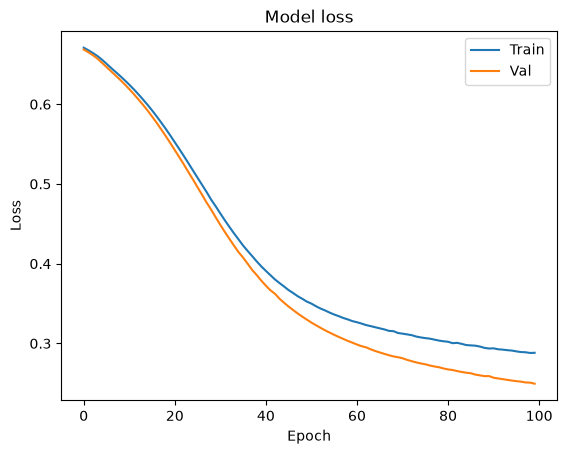

In [81]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

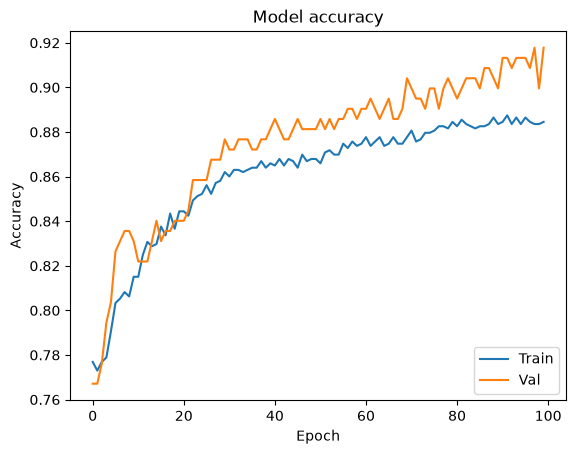

In [82]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

### Demostración de Predicción con el Modelo Entrenado

Ahora, veamos cómo nuestro `modelo` entrenado (el primer modelo que construimos) realiza una predicción sobre un nuevo punto de datos hipotético.

El array `new_house_features` representa una única casa hipotética con 10 características, en el siguiente orden:

1.  **LotArea**: Superficie del lote en pies cuadrados.
2.  **OverallQual**: Calidad general del material y acabado (1-10).
3.  **OverallCond**: Calificación general de la condición (1-9).
4.  **TotalBsmtSF**: Metros cuadrados totales del sótano.
5.  **FullBath**: Número de baños completos sobre el nivel del suelo.
6.  **HalfBath**: Número de medios baños sobre el nivel del suelo.
7.  **BedroomAbvGr**: Número de dormitorios sobre el nivel del suelo (no incluye dormitorios en el sótano).
8.  **TotRmsAbvGrd**: Total de habitaciones sobre el nivel del suelo (no incluye baños).
9.  **Fireplaces**: Número de chimeneas.
10. **GarageArea**: Tamaño del garaje en pies cuadrados.

In [83]:
# Create a new data point for prediction (hypothetical example)
# Ensure features are in the same order as the original training set (X)
# and are within the unscaled value ranges.
# The 10 features are: LotArea, OverallQual, OverallCond, TotalBsmtSF, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageArea

new_house_features = [[8500, 7, 6, 900, 2, 1, 3, 7, 1, 500]] # An example house

# Convert to numpy array and scale using the same MinMaxScaler used for X_scale
import numpy as np
new_house_features_scaled = min_max_scaler.transform(np.array(new_house_features))

print("New house features (scaled):")
print(new_house_features_scaled)

# Perform the prediction with the 'model' (the first trained model)
prediction = model.predict(new_house_features_scaled)

print(f"\nPredicted probability that the price is above the median: {prediction[0][0]:.4f}")

# Interpret the prediction
if prediction[0][0] >= 0.5:
    print("The model predicts that the price of this house will be above the median value.")
else:
    print("The model predicts that the price of this house will be below the median value.")

New house features (scaled):
[[0.03365351 0.66666667 0.625      0.14729951 0.66666667 0.5
  0.375      0.41666667 0.33333333 0.35260931]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Predicted probability that the price is above the median: 0.9297
The model predicts that the price of this house will be above the median value.


The `new_house_features` array represents a single hypothetical house with 10 features, in the following order:

1.  **LotArea**: Lot size in square feet.
2.  **OverallQual**: Overall material and finish quality (1-10).
3.  **OverallCond**: Overall condition rating (1-9).
4.  **TotalBsmtSF**: Total square feet of basement area.
5.  **FullBath**: Number of full bathrooms above grade.
6.  **HalfBath**: Number of half baths above grade.
7.  **BedroomAbvGr**: Number of bedrooms above grade (does not include basement bedrooms).
8.  **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms).
9.  **Fireplaces**: Number of fireplaces.
10. **GarageArea**: Size of garage in square feet.

In [84]:
# Create a new data point for prediction (hypothetical example)
# Ensure features are in the same order as the original training set (X)
# and are within the unscaled value ranges.
# The 10 features are: LotArea, OverallQual, OverallCond, TotalBsmtSF, FullBath, HalfBath, BedroomAbvGr, TotRmsAbvGrd, Fireplaces, GarageArea

new_house_features = [[8500, 7, 6, 900, 2, 1, 3, 7, 1, 500]] # An example house

# Convert to numpy array and scale using the same MinMaxScaler used for X_scale
import numpy as np
new_house_features_scaled = min_max_scaler.transform(np.array(new_house_features))

print("New house features (scaled):")
print(new_house_features_scaled)

# Perform the prediction with the 'model' (the first trained model)
prediction = model.predict(new_house_features_scaled)

print(f"\nPredicted probability that the price is above the median: {prediction[0][0]:.4f}")

# Interpret the prediction
if prediction[0][0] >= 0.5:
    print("The model predicts that the price of this house will be above the median value.")
else:
    print("The model predicts that the price of this house will be below the median value.")

New house features (scaled):
[[0.03365351 0.66666667 0.625      0.14729951 0.66666667 0.5
  0.375      0.41666667 0.33333333 0.35260931]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Predicted probability that the price is above the median: 0.9297
The model predicts that the price of this house will be above the median value.


# Evaluando el Clasificador: la Matriz de Confusión

`model.evaluate` nos dio **un solo número**. Pero un clasificador binario se equivoca de **dos maneras distintas**, y rara vez cuestan lo mismo.

Además quedó un cabo suelto: recién escribimos `if prediction >= 0.5`. La red devuelve una **probabilidad** — ese `0.5` es un **umbral que elegimos nosotros**, no salió del entrenamiento.

## Los cuatro cuadrantes

Con `AboveMedianPrice` (`1` = sobre la mediana), cada casa de prueba cae en un casillero:

|                             | Predijo **Sobre**        | Predijo **Bajo**         |
|-----------------------------|--------------------------|--------------------------|
| **Realmente sobre mediana** | ✅ Verdadero Positivo TP | ❌ Falso Negativo FN     |
| **Realmente bajo mediana**  | ❌ Falso Positivo FP     | ✅ Verdadero Negativo TN |

La diagonal son los aciertos. Y `accuracy = (TP + TN) / total` **colapsa los cuatro casilleros en uno solo**: ahí se pierde la información.

Para una inmobiliaria que decide a qué casas mandar un tasador, un **FP** es un tasador desperdiciado y un **FN** es un negocio perdido. Costos muy distintos — la accuracy los trata igual.

Probabilidades: [0.018 0.532 0.917 0.983 0.982]
Decisiones:     [0 1 1 1 1]   (umbral 0.5)
Realidad:       [0 0 1 1 1]

TP=94 casas caras detectadas | FN=17 se nos escaparon
FP=16 las marcamos caras y no lo eran | TN=92 bien descartadas


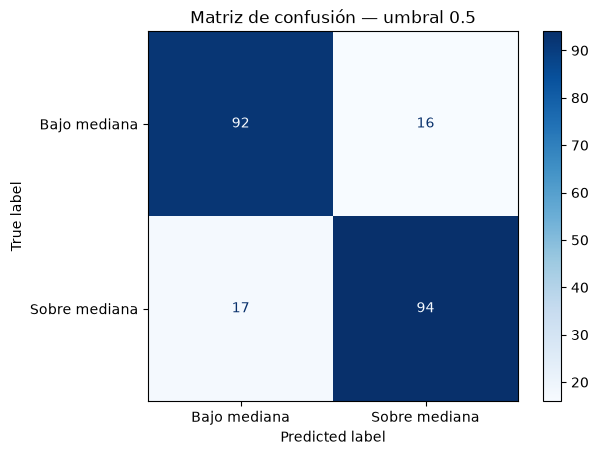

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

class_names = ['Bajo mediana', 'Sobre mediana']

# 1. El modelo devuelve PROBABILIDADES: una por cada casa del conjunto de prueba
y_prob = model.predict(X_test, verbose=0).ravel()

# 2. Nosotros elegimos el THRESHOLD que convierte esas probabilidades en DECISIONES
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)
y_true = Y_test.astype(int)

print(f"Probabilidades: {np.round(y_prob[:5], 3)}")
print(f"Decisiones:     {y_pred[:5]}   (umbral {THRESHOLD})")
print(f"Realidad:       {y_true[:5]}")

# 3. La matriz de confusión compara nuestras decisiones contra la realidad
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"\nTP={tp} casas caras detectadas | FN={fn} se nos escaparon")
print(f"FP={fp} las marcamos caras y no lo eran | TN={tn} bien descartadas")

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de confusión — umbral {THRESHOLD}')
plt.grid(False)
plt.show()

## Accuracy, precision y recall

Tres preguntas distintas sobre los mismos cuatro casilleros:

- **Accuracy** = `(TP + TN) / total` → *de todas las casas, ¿en cuántas acerté?* Es un número **global**; usa los cuatro casilleros.
- **Precision** = `TP / (TP + FP)` → *de las que marqué caras, ¿cuántas lo eran?* Importa cuando **actuar cuesta caro**.
- **Recall** = `TP / (TP + FN)` → *de las caras que había, ¿cuántas detecté?* Importa cuando **perderse un caso cuesta caro** (piensen en un diagnóstico médico).
- **F1** = `2 · (precision · recall) / (precision + recall)` → la **media armónica** de las dos (equivale a `2·TP / (2·TP + FP + FN)`). Se usa cuando necesitás un solo número que las balancee: a diferencia del promedio común, el F1 se hunde si **cualquiera** de las dos es baja.

Dos avisos que ahorran confusiones:

- **Accuracy ≠ precision.** Precision **ignora los TN**; accuracy los cuenta. Acá dan parecido solo porque el dataset está balanceado: con desbalance es normal ver accuracy 0.93 y precision 0.40 en el mismo modelo. Además accuracy es **una sola** por modelo, mientras que precision y recall son **por clase** — por eso el reporte de abajo trae dos filas.
- En español "accuracy" suele traducirse como *precisión*, que es el nombre de **otra** métrica de esta misma lista. Por eso las dejamos en inglés.

Precision y recall están casi siempre en tensión: subir una baja la otra.

In [86]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

               precision    recall  f1-score   support

 Bajo mediana      0.844     0.852     0.848       108
Sobre mediana      0.855     0.847     0.851       111

     accuracy                          0.849       219
    macro avg      0.849     0.849     0.849       219
 weighted avg      0.849     0.849     0.849       219



## El modelo no decide: decide el umbral

La red está congelada — ya entrenó, sus pesos no cambian. Movemos **solo** el `0.5`:

In [87]:
print(f"{'Umbral':>7} | {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>4} | {'Accuracy':>9} {'Precision':>10} {'Recall':>8}")
print("-" * 66)

for t in [0.2, 0.35, 0.5, 0.65, 0.8]:
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, (y_prob >= t).astype(int), labels=[0, 1]).ravel()
    acc  = (tp_t + tn_t) / len(y_true)
    prec = tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 0.0
    rec  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) else 0.0
    print(f"{t:>7.2f} | {tp_t:>4} {fp_t:>4} {fn_t:>4} {tn_t:>4} | {acc:>9.3f} {prec:>10.3f} {rec:>8.3f}")

print("\nUmbral bajo  -> modelo 'generoso': detecta más caras, se equivoca más.")
print("Umbral alto  -> modelo 'exigente': casi no falla al decir 'cara', pero deja escapar.")

 Umbral |   TP   FP   FN   TN |  Accuracy  Precision   Recall
------------------------------------------------------------------
   0.20 |  106   38    5   70 |     0.804      0.736    0.955
   0.35 |  100   23   11   85 |     0.845      0.813    0.901
   0.50 |   94   16   17   92 |     0.849      0.855    0.847
   0.65 |   89    9   22   99 |     0.858      0.908    0.802
   0.80 |   74    5   37  103 |     0.808      0.937    0.667

Umbral bajo  -> modelo 'generoso': detecta más caras, se equivoca más.
Umbral alto  -> modelo 'exigente': casi no falla al decir 'cara', pero deja escapar.


## ¿Y por qué no alcanzaba con la accuracy?

Un detalle honesto: este dataset está **balanceado** (728 contra 732), así que acá la accuracy *sí* es razonable.

El problema aparece con clases **desbalanceadas**, que es lo normal en la vida real (fraude, enfermedades raras, fallas de equipos). Simulémoslo: mismo conjunto de prueba con las casas caras reducidas al 10%, contra un "modelo" que ni mira los datos.

In [88]:
rng = np.random.default_rng(42)

idx_neg = np.where(y_true == 0)[0]
idx_pos = np.where(y_true == 1)[0]
idx_pos_few = rng.choice(idx_pos, size=len(idx_neg) // 9, replace=False)  # deja los positivos en ~10%
idx_imb = np.concatenate([idx_neg, idx_pos_few])

y_true_imb = y_true[idx_imb]
print(f"Conjunto desbalanceado: {len(y_true_imb)} casas, "
      f"{(y_true_imb == 1).sum()} de ellas sobre la mediana "
      f"({100 * (y_true_imb == 1).mean():.1f}%)\n")

# Un "modelo" tramposo que SIEMPRE responde 'bajo la mediana', sin mirar una sola feature:
y_pred_dummy = np.zeros_like(y_true_imb)

acc_dummy = (y_pred_dummy == y_true_imb).mean()
print(f"Accuracy del modelo tramposo: {acc_dummy:.3f}   <-- ¡parece excelente!")
print(confusion_matrix(y_true_imb, y_pred_dummy, labels=[0, 1]))
print("TP = 0 -> recall = 0: no detectó NI UNA casa cara.")
print("La accuracy lo escondía; la matriz, no.")

# Y ahora nuestra red de verdad, sobre exactamente el mismo conjunto:
y_pred_imb = y_pred[idx_imb]
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true_imb, y_pred_imb, labels=[0, 1]).ravel()
print(f"\nNuestra red sobre el mismo conjunto: accuracy={(tp_d + tn_d) / len(y_true_imb):.3f}, "
      f"recall={tp_d / (tp_d + fn_d):.3f}  <-- accuracy parecida, pero SÍ detecta casas caras.")

Conjunto desbalanceado: 120 casas, 12 de ellas sobre la mediana (10.0%)

Accuracy del modelo tramposo: 0.900   <-- ¡parece excelente!
[[108   0]
 [ 12   0]]
TP = 0 -> recall = 0: no detectó NI UNA casa cara.
La accuracy lo escondía; la matriz, no.

Nuestra red sobre el mismo conjunto: accuracy=0.867, recall=1.000  <-- accuracy parecida, pero SÍ detecta casas caras.


### Para llevarse

1. La red devuelve **probabilidades**; la decisión la toma un **umbral** que elegimos nosotros.
2. La matriz muestra *qué tipo* de error cometemos; la accuracy solo *cuántos*.
3. Priorizar precision o recall es una decisión del **negocio**, no del modelo.
4. Con clases desbalanceadas, una accuracy altísima puede esconder un modelo inútil.

Ya sabemos **medir**. Ahora, otro problema: qué pasa cuando el modelo aprende *demasiado* de los datos de entrenamiento — el **sobreajuste**.

# Añadiendo Regularización a Nuestra Red Neuronal

Entrenaremos un modelo que se sobreajustará, al que llamaremos Modelo 2. Esto puede tardar unos minutos.

In [89]:
model_2 = Sequential([
    Dense(1000, activation='relu', input_shape=(10,)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='sigmoid'),
])
model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_2 = model_2.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100


/Users/pveiga/Documents/Austral/talksmith-ing/missions/clase3/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7916 - loss: 0.4422 - val_accuracy: 0.8813 - val_loss: 0.3220
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8659 - loss: 0.3453 - val_accuracy: 0.9087 - val_loss: 0.2858
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8777 - loss: 0.3103 - val_accuracy: 0.8995 - val_loss: 0.2566
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8826 - loss: 0.2787 - val_accuracy: 0.9178 - val_loss: 0.2408
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8826 - loss: 0.2694 - val_accuracy: 0.8813 - val_loss: 0.3962
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8405 - loss: 0.3751 - val_accuracy: 0.9132 - val_loss: 0.2747
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8933 - loss: 0.2501 - val_accuracy: 0.9132 - val_loss: 0.2455
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9031 - loss: 0.2463 - val_accuracy: 0.9224 - val_loss: 0.2

Hagamos la misma visualización para ver cómo se ve el sobreajuste en términos de pérdida y precisión.

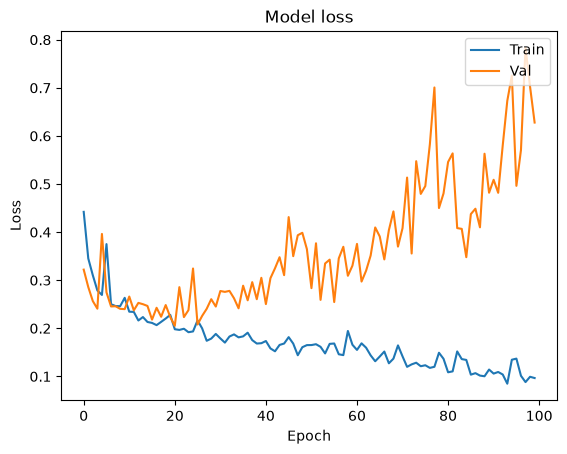

In [90]:
plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

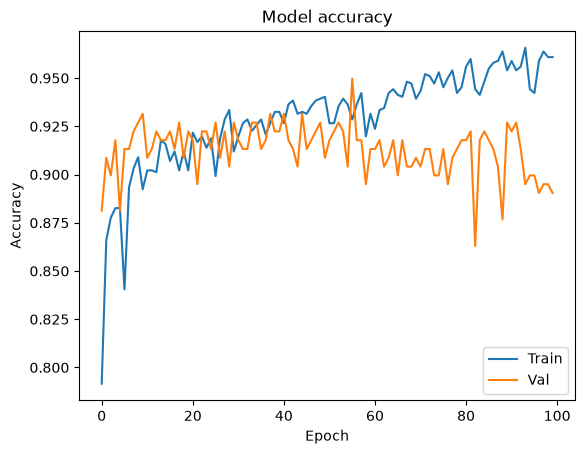

In [91]:
plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

## ¿Qué es la regularización?

El Modelo 2 tiene **3.015.001 parámetros** para aprender de **1022 casas**: unos **2950 parámetros por ejemplo**. Con esa capacidad no necesita *entender* nada — le alcanza con **memorizar**. Eso es el sobreajuste.

**Regularizar es restringirle la libertad al modelo a propósito**: hacerle más difícil memorizar, para forzarlo a quedarse con los patrones que generalizan. El precio es que va a andar *peor* en entrenamiento, y eso es justamente lo que buscamos.

### L2 (weight decay)

Le sumamos a la función de pérdida una multa proporcional al cuadrado de los pesos:

$$\text{pérdida total} = \text{binary crossentropy} + \lambda \sum_i w_i^2$$

Ahora un peso grande le **cuesta** al modelo: solo lo va a agrandar si le rinde de verdad en la crossentropy. El resultado son pesos chicos y repartidos — una función más suave, que es otra forma de decir *menos capaz de memorizar casos puntuales*. En el código: `kernel_regularizer=regularizers.l2(0.01)`, donde `0.01` es λ, cuánto pesa la multa.

Ojo con esto: ese término extra es la razón de que la loss del Modelo 3 **arranque mucho más alta**. No cambiamos de métrica; se le sumó la multa al número reportado.

### Dropout

En cada paso de entrenamiento **apaga neuronas al azar**. Con `Dropout(0.3)`, el 30% de la capa se pone en cero en ese paso, y en el siguiente les toca a otras.

¿Por qué ayuda? Ninguna neurona puede confiar en que una compañera puntual va a estar ahí, así que la red no puede armar detectores frágiles que dependan de un detalle del set de entrenamiento: tiene que **distribuir** lo que aprende. Es parecido a entrenar muchas redes más chicas y promediarlas.

**El dropout solo actúa durante el entrenamiento.** Al predecir (`model.predict`) están todas las neuronas activas; Keras se encarga del ajuste de escala.

### Qué mirar en las gráficas

- La curva de **entrenamiento** va a quedar *peor* que la del Modelo 2. Está bien: es el síntoma de que la restricción funciona.
- Lo que tiene que achicarse es la **brecha** entre entrenamiento y validación.

L2 y dropout no son las únicas herramientas: achicar el modelo, cortar el entrenamiento antes de tiempo (*early stopping*) o conseguir más datos también regularizan.

Con esto armamos el **Modelo 3**: la misma arquitectura del Modelo 2, más L2 y dropout.

In [92]:
from keras.layers import Dropout
from keras import regularizers

In [93]:
model_3 = Sequential([
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(10,)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)),
])

In [94]:
model_3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
hist_3 = model_3.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6292 - loss: 14.2388 - val_accuracy: 0.7991 - val_loss: 3.8695
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8425 - loss: 1.6789 - val_accuracy: 0.8858 - val_loss: 0.6369
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8464 - loss: 0.5826 - val_accuracy: 0.8676 - val_loss: 0.4914
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8454 - loss: 0.5419 - val_accuracy: 0.8493 - val_loss: 0.5170
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8718 - loss: 0.4969 - val_accuracy: 0.8767 - val_loss: 0.4713
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8718 - loss: 0.4959 - val_accuracy: 0.8539 - val_loss: 0.5075
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8757 - loss: 0.4827 - val_accuracy: 0.9178 - val_loss: 0.4160
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8836 - loss: 0.4730 - val_accuracy: 0.9224 - 

Ahora trazaremos los gráficos de pérdida y precisión para el Modelo 3. Notarás que la pérdida es mucho mayor al principio, y esto se debe a que hemos cambiado nuestra función de pérdida. Para graficar de modo que la ventana se amplíe entre 0 y 1.2 para la pérdida, agregamos una línea de código adicional (`plt.ylim`) al graficar.

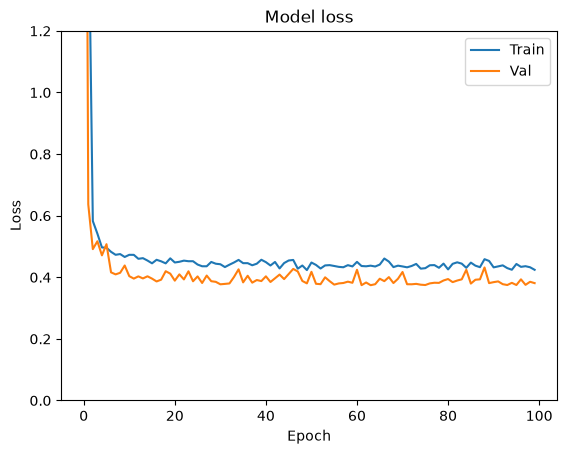

In [95]:
plt.plot(hist_3.history['loss'])
plt.plot(hist_3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.ylim(top=1.2, bottom=0)
plt.show()

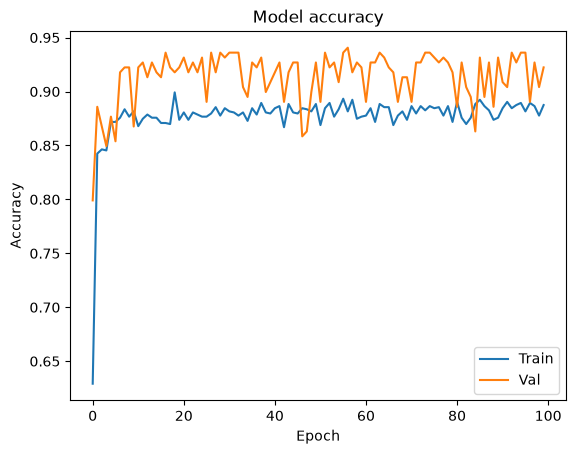

In [96]:
plt.plot(hist_3.history['accuracy'])
plt.plot(hist_3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

En comparación con el Modelo 2, ¡deberías ver que hay menos sobreajuste!

### ¿Por qué hay Overfitting en el Modelo 2?

El **overfitting** (sobreajuste) se produce cuando un modelo de aprendizaje automático aprende los datos de entrenamiento con demasiado detalle, incluyendo el ruido y las particularidades específicas de esos datos, en lugar de aprender los patrones generales que son aplicables a nuevos datos.

En el **Modelo 2**, observamos overfitting por varias razones, que se hacen evidentes al comparar las curvas de entrenamiento y validación en las gráficas de pérdida y precisión:

1.  **Complejidad del Modelo**: El Modelo 2 utiliza cuatro capas ocultas, cada una con 1000 neuronas (`Dense(1000)`). Un modelo con una gran cantidad de parámetros (neuronas y capas) tiene una capacidad muy alta para memorizar los datos de entrenamiento.
2.  **Falta de Regularización**: A diferencia del Modelo 3, el Modelo 2 no incluye técnicas de regularización como L2 (regularización de peso) o Dropout. Estas técnicas están diseñadas específicamente para evitar el overfitting al penalizar pesos grandes o desactivar neuronas aleatoriamente durante el entrenamiento.
3.  **Número de Épocas**: El modelo fue entrenado durante 100 épocas. Sin regularización, entrenar un modelo complejo durante muchas épocas le da amplias oportunidades para "memorizar" los datos de entrenamiento.

**¿Cómo se ve el Overfitting en las Gráficas?**

*   **Pérdida (Loss)**: La `pérdida de entrenamiento` (línea azul) continúa disminuyendo, a menudo acercándose a cero, mientras que la `pérdida de validación` (línea naranja) deja de disminuir en algún punto y comienza a aumentar. Esto indica que el modelo está mejorando en los datos que ha visto, pero empeorando en los datos nuevos y no vistos.
*   **Precisión (Accuracy)**: La `precisión de entrenamiento` (línea azul) sigue aumentando, a menudo acercándose al 100%, mientras que la `precisión de validación` (línea naranja) se estanca o incluso disminuye después de alcanzar un pico. Esto significa que el modelo está aprendiendo las respuestas correctas para los datos de entrenamiento, pero no está generalizando bien a los datos de validación.

En resumen, la combinación de un modelo muy complejo y la ausencia de técnicas para forzarlo a generalizar (regularización) llevó a que el Modelo 2 se sobreajustara a los datos de entrenamiento.